In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [4]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1762255413.714901   51673 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [6]:
print(gender_predictions)

[[9.9875969e-01]
 [9.9793863e-01]
 [9.9840587e-01]
 [9.9657059e-01]
 [9.9734259e-01]
 [9.9890888e-01]
 [9.9837410e-01]
 [9.9832249e-01]
 [9.9826175e-01]
 [9.9827796e-01]
 [9.9887311e-01]
 [9.9871707e-01]
 [9.9882758e-01]
 [9.9893355e-01]
 [9.9897659e-01]
 [9.9801260e-01]
 [9.9888933e-01]
 [9.9868536e-01]
 [9.9918228e-01]
 [9.9909079e-01]
 [9.9930561e-01]
 [9.9900162e-01]
 [9.9880624e-01]
 [9.9848449e-01]
 [9.9904728e-01]
 [9.9847203e-01]
 [9.9892616e-01]
 [9.9817097e-01]
 [9.9795425e-01]
 [9.9887365e-01]
 [9.9916810e-01]
 [9.9916351e-01]
 [9.9740446e-01]
 [9.9933785e-01]
 [9.9927926e-01]
 [9.9923313e-01]
 [9.9915284e-01]
 [9.9899447e-01]
 [9.9901319e-01]
 [9.9928236e-01]
 [9.9945617e-01]
 [9.9929661e-01]
 [9.9920279e-01]
 [9.9816060e-01]
 [9.9926168e-01]
 [9.9490869e-01]
 [9.9894917e-01]
 [9.9896592e-01]
 [9.9919677e-01]
 [9.9900955e-01]
 [9.9902725e-01]
 [9.9901509e-01]
 [9.9859440e-01]
 [9.9934071e-01]
 [9.9842125e-01]
 [9.9905026e-01]
 [9.9816000e-01]
 [9.9572623e-01]
 [9.9881679e-0

In [7]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 295 female samples.


In [8]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,-537.805115,74.499825,16.144732,41.413177,0.090658,4.300513,-14.244553,5.471502,-5.960288,9.901382,...,34.392908,-0.003668,0.055127,-0.018462,-0.017223,-0.005943,-0.015435,1,7,3
291,-564.110962,84.495499,19.121347,53.239677,3.447273,9.294318,-18.866158,7.873207,-4.900262,7.340342,...,32.837789,0.042722,0.025001,-0.008568,-0.125956,-0.019678,0.001777,1,7,3
292,-596.333252,73.893417,15.403625,41.073212,1.869733,11.873602,-11.927804,11.471960,-4.937204,11.824884,...,32.617960,-0.010603,-0.008930,-0.032430,-0.074292,-0.006063,-0.013062,1,7,3
293,-614.704407,77.700470,28.413834,44.943321,2.837741,9.352011,-8.827148,14.472630,-8.238801,5.944623,...,32.883228,-0.020736,0.040788,0.011213,0.010997,0.008227,0.006794,1,7,3


In [9]:
data.iloc[:,-3] == 1

0       True
1       True
2       True
3       True
4       True
       ...  
583    False
584    False
585    False
586    False
587    False
Name: gender, Length: 588, dtype: bool

In [10]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [11]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,17.334037,17.539159,17.562779,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,16.263369,17.699334,19.162629,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,18.860587,18.714656,19.843059,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,15.868680,18.698590,19.053175,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,16.198743,17.339091,18.793145,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,-537.805115,74.499825,16.144732,41.413177,0.090658,4.300513,-14.244553,5.471502,-5.960288,9.901382,...,16.241398,15.746897,17.595882,34.392908,-0.003668,0.055127,-0.018462,-0.017223,-0.005943,-0.015435
291,-564.110962,84.495499,19.121347,53.239677,3.447273,9.294318,-18.866158,7.873207,-4.900262,7.340342,...,15.380592,15.405968,17.496630,32.837789,0.042722,0.025001,-0.008568,-0.125956,-0.019678,0.001777
292,-596.333252,73.893417,15.403625,41.073212,1.869733,11.873602,-11.927804,11.471960,-4.937204,11.824884,...,15.167482,15.816087,16.013140,32.617960,-0.010603,-0.008930,-0.032430,-0.074292,-0.006063,-0.013062
293,-614.704407,77.700470,28.413834,44.943321,2.837741,9.352011,-8.827148,14.472630,-8.238801,5.944623,...,14.666505,15.365860,15.525179,32.883228,-0.020736,0.040788,0.011213,0.010997,0.008227,0.006794


In [12]:
y

0      1
1      1
2      1
3      1
4      1
      ..
290    7
291    7
292    7
293    7
320    2
Name: labels, Length: 295, dtype: int64

In [13]:
X_speaker

0      1
1      1
2      1
3      1
4      1
      ..
290    3
291    3
292    3
293    3
320    4
Name: speaker, Length: 295, dtype: int64

In [14]:
X.shape, y.shape

((295, 193), (295,))

In [15]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [16]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
273,-416.117096,86.514755,-14.948741,24.314396,-15.377453,-12.961892,-7.946152,-4.623827,-20.749578,0.566477,...,18.762496,17.728123,19.758318,35.221979,0.005141,-0.012488,-0.011515,0.006081,0.001580,-0.005655
155,-248.843781,50.070225,-38.096260,33.250271,-22.841396,-16.792681,-26.519135,8.590793,-27.914560,0.630480,...,18.107102,18.995581,20.955237,36.904346,-0.005018,-0.033043,0.114935,-0.029963,0.008580,0.003583
84,-453.831665,75.665146,5.823720,30.844810,6.042925,-0.197116,-11.119115,12.453388,-0.400404,4.712238,...,14.758724,15.473366,17.762782,33.030419,0.013788,-0.004005,-0.029462,0.000307,-0.003503,-0.014484
82,-420.218597,64.062325,-0.281118,43.151077,-10.717179,-9.781115,-12.968027,13.550075,-5.233039,6.118246,...,20.294380,17.207020,18.982126,35.738948,0.004295,0.034112,-0.003913,-0.113101,0.014248,-0.004861
261,-361.907593,64.413483,-69.818825,5.458014,-22.811913,-20.750097,-16.863075,0.161085,-30.165892,8.593779,...,20.262439,20.243523,22.052062,36.845911,-0.002936,0.033041,-0.016694,-0.086253,0.015828,-0.001420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,-376.696136,100.545700,-2.067171,16.801201,-4.861701,-5.283474,-19.274145,-2.049540,-11.216241,4.037368,...,18.452378,17.810006,16.937227,33.130914,0.056024,-0.013460,-0.098905,-0.001561,-0.000093,0.042343
71,-483.981812,48.379009,14.355464,43.422832,-13.121336,-6.838452,-2.321568,14.630364,-14.400576,-1.943750,...,17.188606,17.620220,18.394488,33.857580,0.019633,0.047134,-0.041484,-0.017645,0.009781,0.021665
106,-344.833313,72.097519,-15.943831,36.209465,-5.945903,-10.347607,-26.619682,-1.246971,-12.959381,-1.500720,...,19.143630,19.550646,18.435443,35.547995,0.024208,-0.016256,0.009379,-0.058329,-0.003104,-0.028892
270,-372.491058,94.188080,-21.024170,9.422773,-15.271385,-12.616859,-24.407717,-11.172367,-18.123978,5.479527,...,18.217055,18.122454,20.140428,34.772376,0.017319,0.041060,-0.076976,-0.037609,0.009241,0.028595


In [17]:
X_speaker

273    3
155    2
84     1
82     1
261    3
      ..
188    2
71     1
106    2
270    3
102    2
Name: speaker, Length: 295, dtype: int64

In [18]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [19]:
y1

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(295, 7))

In [20]:
X.shape, y1.shape

((295, 193), (295, 7))

In [21]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [22]:
X2.shape, X2_speaker.shape, y2.shape

((295, 193), (295,), (295,))

In [23]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [24]:
import random, numpy as np
from keras import optimizers
kfold=3
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [25]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-416.117096,86.514755,-14.948741,24.314396,-15.377453,-12.961892,-7.946152,-4.623827,-20.749578,0.566477,...,18.762496,17.728123,19.758318,35.221979,0.005141,-0.012488,-0.011515,0.006081,0.001580,-0.005655
1,-248.843781,50.070225,-38.096260,33.250271,-22.841396,-16.792681,-26.519135,8.590793,-27.914560,0.630480,...,18.107102,18.995581,20.955237,36.904346,-0.005018,-0.033043,0.114935,-0.029963,0.008580,0.003583
2,-453.831665,75.665146,5.823720,30.844810,6.042925,-0.197116,-11.119115,12.453388,-0.400404,4.712238,...,14.758724,15.473366,17.762782,33.030419,0.013788,-0.004005,-0.029462,0.000307,-0.003503,-0.014484
3,-420.218597,64.062325,-0.281118,43.151077,-10.717179,-9.781115,-12.968027,13.550075,-5.233039,6.118246,...,20.294380,17.207020,18.982126,35.738948,0.004295,0.034112,-0.003913,-0.113101,0.014248,-0.004861
4,-361.907593,64.413483,-69.818825,5.458014,-22.811913,-20.750097,-16.863075,0.161085,-30.165892,8.593779,...,20.262439,20.243523,22.052062,36.845911,-0.002936,0.033041,-0.016694,-0.086253,0.015828,-0.001420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,-376.696136,100.545700,-2.067171,16.801201,-4.861701,-5.283474,-19.274145,-2.049540,-11.216241,4.037368,...,18.452378,17.810006,16.937227,33.130914,0.056024,-0.013460,-0.098905,-0.001561,-0.000093,0.042343
291,-483.981812,48.379009,14.355464,43.422832,-13.121336,-6.838452,-2.321568,14.630364,-14.400576,-1.943750,...,17.188606,17.620220,18.394488,33.857580,0.019633,0.047134,-0.041484,-0.017645,0.009781,0.021665
292,-344.833313,72.097519,-15.943831,36.209465,-5.945903,-10.347607,-26.619682,-1.246971,-12.959381,-1.500720,...,19.143630,19.550646,18.435443,35.547995,0.024208,-0.016256,0.009379,-0.058329,-0.003104,-0.028892
293,-372.491058,94.188080,-21.024170,9.422773,-15.271385,-12.616859,-24.407717,-11.172367,-18.123978,5.479527,...,18.217055,18.122454,20.140428,34.772376,0.017319,0.041060,-0.076976,-0.037609,0.009241,0.028595


In [26]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,3
1,2
2,1
3,1
4,3
...,...
290,2
291,1
292,2
293,3


In [27]:
speakers = X_speaker.unique()
speakers

array([3, 2, 1, 4])

In [28]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,3
1,2
2,1
3,1
4,3
...,...
290,2
291,1
292,2
293,3


In [29]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-416.117096,86.514755,-14.948741,24.314396,-15.377453,-12.961892,-7.946152,-4.623827,-20.749578,0.566477,...,17.728123,19.758318,35.221979,0.005141,-0.012488,-0.011515,0.006081,0.001580,-0.005655,3
1,-248.843781,50.070225,-38.096260,33.250271,-22.841396,-16.792681,-26.519135,8.590793,-27.914560,0.630480,...,18.995581,20.955237,36.904346,-0.005018,-0.033043,0.114935,-0.029963,0.008580,0.003583,2
2,-453.831665,75.665146,5.823720,30.844810,6.042925,-0.197116,-11.119115,12.453388,-0.400404,4.712238,...,15.473366,17.762782,33.030419,0.013788,-0.004005,-0.029462,0.000307,-0.003503,-0.014484,1
3,-420.218597,64.062325,-0.281118,43.151077,-10.717179,-9.781115,-12.968027,13.550075,-5.233039,6.118246,...,17.207020,18.982126,35.738948,0.004295,0.034112,-0.003913,-0.113101,0.014248,-0.004861,1
4,-361.907593,64.413483,-69.818825,5.458014,-22.811913,-20.750097,-16.863075,0.161085,-30.165892,8.593779,...,20.243523,22.052062,36.845911,-0.002936,0.033041,-0.016694,-0.086253,0.015828,-0.001420,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,-376.696136,100.545700,-2.067171,16.801201,-4.861701,-5.283474,-19.274145,-2.049540,-11.216241,4.037368,...,17.810006,16.937227,33.130914,0.056024,-0.013460,-0.098905,-0.001561,-0.000093,0.042343,2
291,-483.981812,48.379009,14.355464,43.422832,-13.121336,-6.838452,-2.321568,14.630364,-14.400576,-1.943750,...,17.620220,18.394488,33.857580,0.019633,0.047134,-0.041484,-0.017645,0.009781,0.021665,1
292,-344.833313,72.097519,-15.943831,36.209465,-5.945903,-10.347607,-26.619682,-1.246971,-12.959381,-1.500720,...,19.550646,18.435443,35.547995,0.024208,-0.016256,0.009379,-0.058329,-0.003104,-0.028892,2
293,-372.491058,94.188080,-21.024170,9.422773,-15.271385,-12.616859,-24.407717,-11.172367,-18.123978,5.479527,...,18.122454,20.140428,34.772376,0.017319,0.041060,-0.076976,-0.037609,0.009241,0.028595,3


In [30]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(3).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [3 2 1]


In [31]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=294
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emovo_speaker_female_193'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 3
Train speakers: [1 2 4]
No overlap in fold 0.
Top 125 features: [ 17  43   3 155  38   6  91  75 162  83] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2081 - loss: 2.1932 - val_accuracy: 0.1429 - val_loss: 1.9441
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3147 - loss: 1.7292 - val_accuracy: 0.1429 - val_loss: 1.9478
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4619 - loss: 1.4763 - val_accuracy: 0.1429 - val_loss: 1.9512
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5685 - loss: 1.3154 - val_accuracy: 0.1429 - val_loss: 1.9555
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5736 - loss: 1.2711 - val_accuracy: 0.1429 - val_loss: 1.9586
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6650 - loss: 1.1524 - val_accuracy: 0.1429 - val_loss: 1.9615
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6802 - loss: 1.1247 - val_accuracy: 0.1429 - val_loss: 1.9660
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7056 - loss: 1.0768 - val_accuracy: 0.1429 - val_loss: 1.9725
Epoc

Fold 0 Test Accuracy: 0.3367

===== Fold 1 =====
Test speaker: 2
Train speakers: [1 3 4]
No overlap in fold 1.
Top 125 features: [  2  59   0  91  17   5  81  20  61 106] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1726 - loss: 2.3204 - val_accuracy: 0.1020 - val_loss: 1.9810
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2741 - loss: 1.7984 - val_accuracy: 0.1224 - val_loss: 1.9939
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4010 - loss: 1.6116 - val_accuracy: 0.1224 - val_loss: 1.9934
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4315 - loss: 1.5068 - val_accuracy: 0.1122 - val_loss: 1.9998
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5076 - loss: 1.3911 - val_accuracy: 0.1122 - val_loss: 2.0132
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5482 - loss: 1.3483 - val_accuracy: 0.1224 - val_loss: 2.0027
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6091 - loss: 1.2624 - val_accuracy: 0.1224 - val_loss: 2.0103
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5888 - loss: 1.2448 - val_accuracy: 0.0816 - val_loss: 2.0115
Epoc

Fold 1 Test Accuracy: 0.2449

===== Fold 2 =====
Test speaker: 1
Train speakers: [2 3 4]
No overlap in fold 2.
Top 125 features: [ 31  15   0 119   1   3 116  75   4  64] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.1980 - loss: 2.1566 - val_accuracy: 0.1122 - val_loss: 1.9538
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3604 - loss: 1.7070 - val_accuracy: 0.1327 - val_loss: 1.9608
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4975 - loss: 1.4846 - val_accuracy: 0.1429 - val_loss: 1.9601
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5228 - loss: 1.3578 - val_accuracy: 0.1429 - val_loss: 1.9651
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5939 - loss: 1.2437 - val_accuracy: 0.1429 - val_loss: 1.9713
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6244 - loss: 1.1928 - val_accuracy: 0.1429 - val_loss: 1.9780
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7157 - loss: 1.0812 - val_accuracy: 0.1224 - val_loss: 1.9806
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7310 - loss: 1.0404 - val_accuracy: 0.1122 - val_loss: 1.9943
Epoc

Fold 2 Test Accuracy: 0.2653

===== Cross-validation results =====
Fold 0: Loss=1.8227, Accuracy=0.3367
Fold 1: Loss=2.3123, Accuracy=0.2449
Fold 2: Loss=2.0081, Accuracy=0.2653

Average accuracy: 0.2823


In [3]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emovo_speaker_female_193'
num_folds = 3
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

print("\nMean Accuracy: %.2f%%" % np.mean(accuracies))
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
print("95%% CI: ± %.2f" % ci95)


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Fold 0: Accuracy = 33.67%
Fold 1: Accuracy = 24.49%
Fold 2: Accuracy = 26.53%

Mean Accuracy: 28.23%
SD Accuracy: 3.94
95% CI: ± 4.46


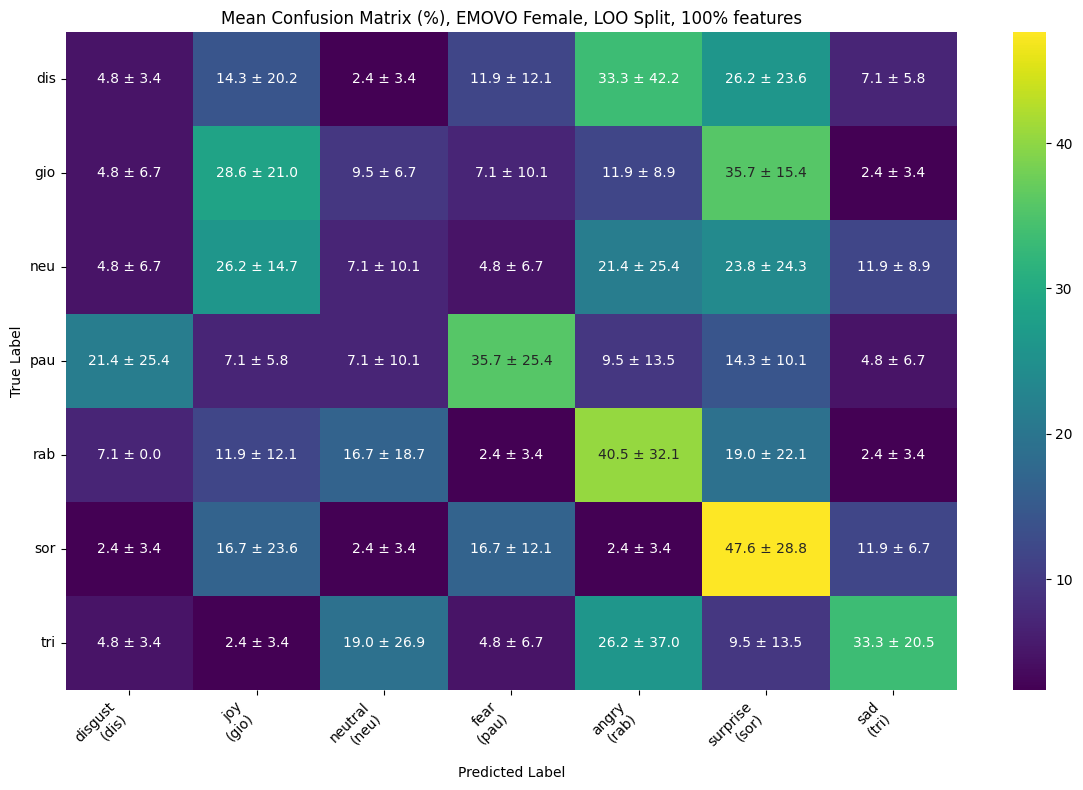

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_emovo_speaker_female_193.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        labels[i, j] = f"{mean_cm[i, j]:.1f} ± {std_cm[i, j]:.1f}"

y_list = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']
x_list = ['disgust\n(dis)', 'joy\n(gio)', 'neutral\n(neu)','fear\n(pau)', 'angry\n(rab)', 'surprise\n(sor)', 'sad\n(tri)']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(x_list)) + 0.5)
ax.set_yticks(np.arange(len(y_list)) + 0.5)
ax.set_xticklabels(x_list, rotation=45, ha="right")
ax.set_yticklabels(y_list, rotation=0)

plt.title("Mean Confusion Matrix (%), EMOVO Female, LOO Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
